<div style="padding: 32px; border: 1px solid #f1f5f9; border-left: 6px solid #FFDE42; background-color: #ffffff; border-radius: 16px; box-shadow: 0 10px 30px -5px rgba(17, 31, 162, 0.06); font-family: 'Segoe UI', system-ui, -apple-system, sans-serif; max-width: 850px;">

  <div style="margin-bottom: 8px;">
    <span style="color: #111FA2; font-size: 14px; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase;">
      Data Analyst Portfolio
    </span>
  </div>

<h2 style="
    margin: 0 0 14px;color: #5478FF;font-size: 28px;font-weight: 800;line-height: 1.3;text-align: center;
">
    FRAUD DETECTION PADA DATA TRANSAKSI
</h2>

  <!-- <p style="margin: 0 0 28px; color: #475569; font-size: 16px; line-height: 1.6;">
    Analisis <strong style="color: #111FA2; background-color: #f0f9ff; border-bottom: 2px solid #53CBF3; padding: 2px 6px; border-radius: 4px;">6,3 juta transaksi keuangan</strong> untuk mengidentifikasi pola dan karakteristik transaksi yang berpotensi <em>fraud</em>.
  </p>
 -->
  <!-- Bagian Metadata / Badges -->
  <!-- <div style="display: flex; flex-wrap: wrap; gap: 12px; font-size: 13px; font-weight: 600;">
    <div style="display: flex; align-items: center; gap: 8px; background-color: #111FA2; color: #ffffff; padding: 8px 16px; border-radius: 8px; box-shadow: 0 2px 4px rgba(17, 31, 162, 0.2);">
      <span style="font-size: 14px;">📁</span> Financial Transaction Data
    </div>
    <div style="display: flex; align-items: center; gap: 8px; background-color: #5478FF; color: #ffffff; padding: 8px 16px; border-radius: 8px; box-shadow: 0 2px 4px rgba(84, 120, 255, 0.2);">
      <span style="font-size: 14px;">📊</span> ±6,3 Juta Transaksi
    </div>
    <div style="display: flex; align-items: center; gap: 8px; background-color: #53CBF3; color: #111FA2; padding: 8px 16px; border-radius: 8px; box-shadow: 0 2px 4px rgba(83, 203, 243, 0.2);">
      <span style="font-size: 14px;">🎯</span> EDA & Fraud Detection
    </div>
  </div> -->

</div>

In [104]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from __future__ import annotations
import numpy as np
from scipy.spatial.distance import cdist
from __future__ import annotations
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from __future__ import annotations

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [105]:
df = pd.read_csv("/kaggle/input/datasets/amanalisiddiqui/fraud-detection-dataset/AIML Dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [106]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


<div style="
    margin-top: 30px;
    padding: 16px 22px;
    border-left: 6px solid #5478FF;
    background: linear-gradient(135deg, #F8FBFF 0%, #EEF3FF 100%);
    border-radius: 8px;
">

<h2 style="
    margin: 0;
    color: #111FA2;
    font-size: 24px;
">
EXPLORATORY DATA ANALYSIS
</h2>
</div>

Total Transaksi Normal : 6,354,407
Total Transaksi Fraud  : 8,213
Persentase Fraud       : 0.129%


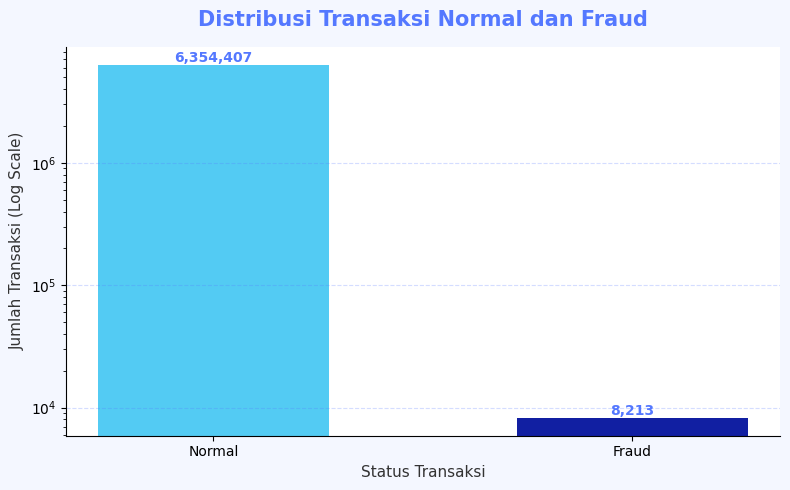

In [107]:
# Cek Imbalanced Data
fraud_counts = df["isFraud"].value_counts().sort_index()
fraud_percentage = (fraud_counts[1] / len(df)) * 100

print(f"Total Transaksi Normal : {fraud_counts[0]:,}")
print(f"Total Transaksi Fraud  : {fraud_counts[1]:,}")
print(f"Persentase Fraud       : {fraud_percentage:.3f}%")

# Warna dari palette
COLOR_NORMAL = "#53CBF3"
COLOR_FRAUD = "#111FA2"
COLOR_ACCENT = "#5478FF"
COLOR_HIGHLIGHT = "#FFDE42"
COLOR_BG = "#F4F7FF"

fig, ax = plt.subplots(figsize=(8, 5))

# Background
fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor("#FFFFFF")

# Bar chart
bars = ax.bar(
    ["Normal", "Fraud"],
    fraud_counts.values,
    color=[COLOR_NORMAL, COLOR_FRAUD],
    width=0.55
)

# Log scale karena sangat imbalanced
ax.set_yscale("log")

# Judul & label
ax.set_title(
    "Distribusi Transaksi Normal dan Fraud",
    fontsize=15,
    fontweight="bold",
    color=COLOR_ACCENT,
    pad=15
)

ax.set_xlabel(
    "Status Transaksi",
    fontsize=11,
    color="#333333"
)

ax.set_ylabel(
    "Jumlah Transaksi (Log Scale)",
    fontsize=11,
    color="#333333"
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.25,
    color=COLOR_ACCENT
)

# Hilangkan border atas & kanan
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Nilai di atas bar
for bar, value in zip(bars, fraud_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=COLOR_ACCENT
    )

plt.tight_layout()
plt.show()

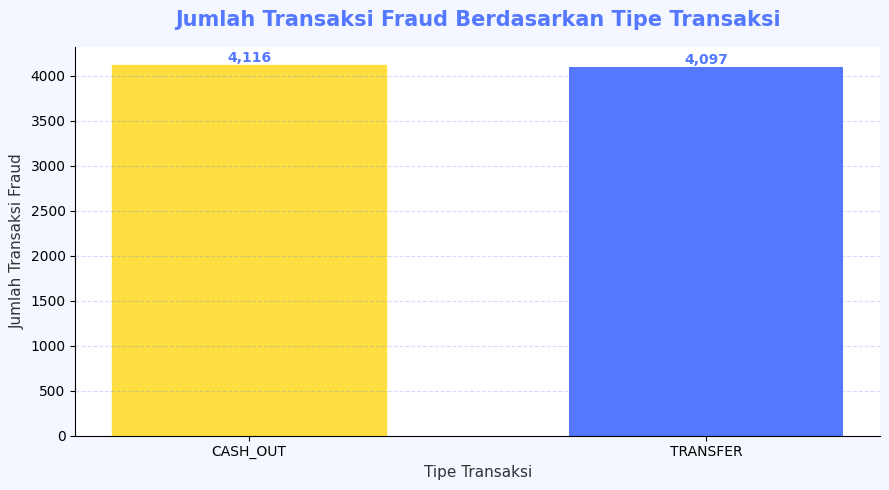

In [108]:
# Jumlah Transaksi Fraud
fraud_by_type = (
    df[df["isFraud"] == 1]["type"]
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))

# Background
fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor("#FFFFFF")

# Bar chart
bars = ax.bar(
    fraud_by_type.index,
    fraud_by_type.values,
    color=COLOR_ACCENT,
    width=0.6
)

# Highlight bar dengan jumlah fraud tertinggi
bars[0].set_color(COLOR_HIGHLIGHT)

# Judul
ax.set_title(
    "Jumlah Transaksi Fraud Berdasarkan Tipe Transaksi",
    fontsize=15,
    fontweight="bold",
    color=COLOR_ACCENT,
    pad=15
)

ax.set_xlabel(
    "Tipe Transaksi",
    fontsize=11,
    color="#333333"
)

ax.set_ylabel(
    "Jumlah Transaksi Fraud",
    fontsize=11,
    color="#333333"
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.25,
    color=COLOR_ACCENT
)

# Hilangkan border
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Nilai di atas bar
for bar, value in zip(bars, fraud_by_type.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=COLOR_ACCENT
    )

plt.tight_layout()
plt.show()

In [109]:
# Total Kerugian Finansial akibat Fraud
fraud_df = df[df['isFraud'] == 1]
total_loss = fraud_df['amount'].sum()
print(f"Total Kerugian Finansial akibat Fraud: ${total_loss:,.2f}")

Total Kerugian Finansial akibat Fraud: $12,056,415,427.84


In [110]:
# Evaluasi Sistem Lama (isFlaggedFraud)
confusion_old = pd.crosstab(
    df['isFraud'],
    df['isFlaggedFraud'],
    rownames=['Actual Fraud'],
    colnames=['Flagged by System']
)

# Membuat label yang lebih mudah dibaca
confusion_old.index = ['Not Fraud', 'Fraud']
confusion_old.columns = ['Not Flagged', 'Flagged']

display(confusion_old)

,Not Flagged,Flagged
Not Fraud,6354407,0
Fraud,8197,16


In [111]:
# Recall Sistem Lama
true_positives = len(
    df[
        (df['isFraud'] == 1) &
        (df['isFlaggedFraud'] == 1)
    ]
)

total_actual_fraud = len(
    df[df['isFraud'] == 1]
)

recall_old_system = (
    true_positives / total_actual_fraud
) * 100

print(f"True Positives: {true_positives:,}")
print(f"Total Actual Fraud: {total_actual_fraud:,}")
print(f"Recall Sistem Lama: {recall_old_system:.4f}%")

True Positives: 16
Total Actual Fraud: 8,213
Recall Sistem Lama: 0.1948%


In [112]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

<div style="
    margin-top: 30px;
    padding: 16px 22px;
    border-left: 6px solid #5478FF;
    background: linear-gradient(135deg, #F8FBFF 0%, #EEF3FF 100%);
    border-radius: 8px;
">

<h2 style="
    margin: 0;
    color: #111FA2;
    font-size: 24px;
">
PROBLEM STATEMENT
</h2>
</div>

<div align="justify">

1. Transaksi fraud merupakan transaksi yang sangat merugikan perusahaan. Berdasarkan data, total kerugian akibat transaksi fraud mencapai sekitar <b>$12,056,415,427.84</b>. Fraud terjadi pada data transaksi <b>CASH_OUT</b> dan <b>TRANSFER</b>

2. Perusahaan telah mencoba mengatasi permasalahan tersebut dengan membangun sistem deteksi fraud yang direpresentasikan oleh kolom <code>isFlaggedFraud</code>. Namun, sistem masih belum mampu mendeteksi fraud dengan baik, dengan recall sistem lama yang hanya mencapai <b>0.1948%</b>.

3. Pengembangan sistem deteksi fraud baru juga menghadapi tantangan <i>class imbalance</i>. Data menunjukkan bahwa transaksi fraud hanya berjumlah sekitar <b>8,213 transaksi</b>, sedangkan transaksi non-fraud mencapai sekitar <b>6 juta transaksi</b>.

</div>


<div style="
    margin-top: 30px;
    padding: 16px 22px;
    border-left: 6px solid #5478FF;
    background: linear-gradient(135deg, #F8FBFF 0%, #EEF3FF 100%);
    border-radius: 8px;
">

<h2 style="
    margin: 0;
    color: #111FA2;
    font-size: 24px;
">
DATA PRE-PROCESSING 
</h2>
</div>

Dari EDA fraud hanya terjadi pada data transaksi <code>CASH_OUT</code> dan <code>TRANSFER</code>, maka untuk meringankan komputasi, data transaksi tipe yang lain dihapus.

In [113]:
df_model = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
df_model
# df_model.info()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


Kolom-kolom yang tidak relevan dibuang seperti <code>step, nameOrig, nameDest</code> yang secara tidak langsung berhubungan dengan suatu transaksi yang digolongkan ke fraud atau tidak dan <code>isFlaggedFraud</code> karena hanya hasil deteksi dari sistem lama.

In [114]:
cols_to_drop=['step','nameOrig', 'nameDest', 'isFlaggedFraud']
df_model = df_model.drop(columns=cols_to_drop)
print("Drop Kolom Berhasil")

Drop Kolom Berhasil


In [115]:
df_model

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0
1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0
2,TRANSFER,181.00,181.00,0.00,0.00,0.00,1
3,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1
4,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0
...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1
6362616,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1
6362617,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1
6362618,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1


<div style="
    margin-top: 30px;
    padding: 16px 22px;
    border-left: 6px solid #5478FF;
    background: linear-gradient(135deg, #F8FBFF 0%, #EEF3FF 100%);
    border-radius: 8px;
">

<h2 style="
    margin: 0;
    color: #111FA2;
    font-size: 24px;
">
FEATURE ENGINEERING 
</h2>
</div>

<p align="justify">Untuk melihat anomali pada rekening pengirim, dibuat fitur <code>errorBalancingOrig</code>. Alasanya, seharusnya saat pengirim melakukan transaksi penarikan uang, Saldo Baru haruslah sama dengan Saldo Lama dikurang dengan Nominal yang ditarik. Jika hasil perhitungan ini bernilai 0, maka transaksi tersebut wajar. Namun, jika nilainya bukan 0 (terdapat selisih), maka hal ini menjadi indikator adanya kemungkinan manipulasi atau potensi fraud pada rekening pengirim.</p>

In [116]:
df_model['errorBalanceOrig'] = df_model['newbalanceOrig']+df_model['amount']-df_model['oldbalanceOrg']
df_model

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig
0,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0.0
1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,0.0
2,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0.0
3,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,0.0
4,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0.0
...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,0.0
6362616,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,0.0
6362617,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0.0
6362618,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,0.0


Begitu pula untuk rekening penerima, dibuat fitur <code>errorBalanceDest</code>. Logika normalnya, Saldo Baru penerima haruslah sama dengan Saldo Lama ditambah dengan Nominal uang yang masuk. Jika hasil perhitungannya bernilai selain 0, ini menandakan adanya kejanggalan pada aliran dana di sisi penerima.

In [117]:
df_model['errorBalanceDest']=df_model['oldbalanceDest']+df_model['amount']-df_model['newbalanceDest']
df_model

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest
0,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0.0,9.839640e+03
1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,0.0,1.864280e+03
2,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0.0,1.810000e+02
3,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,0.0,2.136300e+04
4,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0.0,1.166814e+04
...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,0.0,0.000000e+00
6362616,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,0.0,6.311409e+06
6362617,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0.0,1.000000e-02
6362618,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,0.0,8.500025e+05


In [118]:
# Encoding Fitur Kategorikal
df_model['type']=df_model['type'].map({'TRANSFER':0, 'CASH_OUT':1})
df_model

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest
0,4,9839.64,170136.00,160296.36,0.00,0.00,0,0.0,9.839640e+03
1,4,1864.28,21249.00,19384.72,0.00,0.00,0,0.0,1.864280e+03
2,0,181.00,181.00,0.00,0.00,0.00,1,0.0,1.810000e+02
3,1,181.00,181.00,0.00,21182.00,0.00,1,0.0,2.136300e+04
4,4,11668.14,41554.00,29885.86,0.00,0.00,0,0.0,1.166814e+04
...,...,...,...,...,...,...,...,...,...
6362615,1,339682.13,339682.13,0.00,0.00,339682.13,1,0.0,0.000000e+00
6362616,0,6311409.28,6311409.28,0.00,0.00,0.00,1,0.0,6.311409e+06
6362617,1,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0.0,1.000000e-02
6362618,0,850002.52,850002.52,0.00,0.00,0.00,1,0.0,8.500025e+05


### Dataset Akhir untuk Pemodelan

In [119]:
print(f"Jumlah baris data sekarang: {len(df_model):,}")
display(df_model.head())

Jumlah baris data sekarang: 6,362,620


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest
0,4,9839.64,170136.0,160296.36,0.0,0.0,0,0.0,9839.64
1,4,1864.28,21249.0,19384.72,0.0,0.0,0,0.0,1864.28
2,0,181.00,181.0,0.00,0.0,0.0,1,0.0,181.00
3,1,181.00,181.0,0.00,21182.0,0.0,1,0.0,21363.00
4,4,11668.14,41554.0,29885.86,0.0,0.0,0,0.0,11668.14


<div style="
    margin-top: 30px;
    padding: 16px 22px;
    border-left: 6px solid #5478FF;
    background: linear-gradient(135deg, #F8FBFF 0%, #EEF3FF 100%);
    border-radius: 8px;
">

<h2 style="
    margin: 0;
    color: #111FA2;
    font-size: 24px;
">
SPLITTING DATA
</h2>
</div>

In [120]:
# Prediktor dan Target
X = df_model.drop(columns='isFraud')
y = df_model['isFraud']

In [121]:
# Split Data : Training(80) dan Test(20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [122]:
# Distribusi target Data Training
print(f"Sebelum Balancing : ")
print(y_train.value_counts())

Sebelum Balancing : 
isFraud
0    5083526
1       6570
Name: count, dtype: int64


<div style="
    margin-top: 30px;
    padding: 16px 22px;
    border-left: 6px solid #5478FF;
    background: linear-gradient(135deg, #F8FBFF 0%, #EEF3FF 100%);
    border-radius: 8px;
">

<h2 style="
    margin: 0;
    color: #111FA2;
    font-size: 24px;
">
PENANGANAN CLASS IMBALANCED
</h2>
</div>

Untuk menangani <code>CLASS IMBALANCE</code> akan digunakan metode oversampling berbasis SMOTE yaitu <code>AF-SMOTE</code> , yang terbukti efektif untuk menangani ekstreem class imbalance.

AF-SMOTE : <code>Yu, Y., Hughes, M. S., Lee, J., Zhou, J., & Laine, A. F. (2026). Boundary-aware adversarial filtering for reliable diagnosis under extreme class imbalance. 2026 IEEE 23rd International Symposium on Biomedical Imaging (ISBI), 1–5. https://doi.org/10.1109/ISBI61048.2026.11515910</code>

In [123]:
def _sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def _logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

class AFSMOTE:
    def __init__(
        self,
        target_ratio=1.0,
        over_generation_ratio=3.0,
        smote_k=5,
        lam=0.5,
        tau=0.3,
        alpha=1.0,
        base_threshold=0.5,
        discriminator=None,
        boundary_model=None,
        discriminator_folds=5,
        selection="topk",
        pca_components=None,
        random_state=None,
        verbose=True,
    ):
        if selection not in ("topk", "threshold"):
            raise ValueError("selection harus 'topk' atau 'threshold'.")

        self.target_ratio = target_ratio
        self.over_generation_ratio = over_generation_ratio
        self.smote_k = smote_k
        self.lam = lam
        self.tau = tau
        self.alpha = alpha
        self.base_threshold = base_threshold

        self.discriminator = (
            discriminator if discriminator is not None else LogisticRegression(max_iter=1000)
        )
        self.boundary_model = (
            boundary_model
            if boundary_model is not None
            else GradientBoostingClassifier(random_state=random_state)
        )
        self.discriminator_folds = discriminator_folds
        self.selection = selection
        self.pca_components = pca_components
        self.random_state = random_state
        self.verbose = verbose

        self.scores_ = None

    # API utama
    def fit_resample(self, X, y):
        rng = np.random.default_rng(self.random_state)
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)

        classes, counts = np.unique(y, return_counts=True)
        if len(classes) != 2:
            raise ValueError("AFSMOTE hanya mendukung klasifikasi biner (2 kelas).")

        min_class = classes[np.argmin(counts)]
        maj_class = classes[np.argmax(counts)]

        X_min = X[y == min_class]
        X_maj = X[y == maj_class]
        n_min, n_maj = len(X_min), len(X_maj)

        if n_min < 2:
            raise ValueError(
                "Perlu minimal 2 sampel minoritas untuk interpolasi SMOTE."
            )

        self._log(f"Minority: {n_min:,} | Majority: {n_maj:,}")

        if n_min >= n_maj:
            return X.copy(), y.copy()

        target_min = int(min(n_maj, np.ceil(self.target_ratio * n_maj)))
        n_needed = target_min - n_min
        if n_needed <= 0:
            return X.copy(), y.copy()

        # PCA front-end untuk data dimensi tinggi
        pca = None
        X_min_proc, X_maj_proc = X_min, X_maj
        if self.pca_components is not None:
            pca = PCA(n_components=self.pca_components, random_state=self.random_state)
            pca.fit(X)
            X_min_proc = pca.transform(X_min)
            X_maj_proc = pca.transform(X_maj)
            self._log(f"PCA front-end: {X.shape[1]}D -> {self.pca_components}D")

        # over-generate kandidat SMOTE
        n_candidates = max(n_needed, int(np.ceil(n_needed * self.over_generation_ratio)))
        # self._log(
        #     f"Generating {n_candidates:,} kandidat SMOTE "
        #     f"(butuh {n_needed:,}, over-generation x{self.over_generation_ratio})..."
        # )
        candidates = self._smote_candidates(X_min_proc, n_candidates, rng)

        # skor realisme s_real 
        # self._log("Menghitung skor realisme (discriminator, cross-fitted)...")
        s_real = self._discriminator_scores(X_min_proc, candidates, rng)

        # skor utilitas boundary s_util
        # self._log("Menghitung skor utilitas boundary...")
        X_full_proc = np.vstack([X_min_proc, X_maj_proc])
        y_full = np.concatenate([np.full(n_min, min_class), np.full(n_maj, maj_class)])

        boundary = clone(self.boundary_model)
        boundary.fit(X_full_proc, y_full)

        pos_idx = list(boundary.classes_).index(min_class)
        p_hat = boundary.predict_proba(candidates)[:, pos_idx]

        d_boundary = np.abs(_logit(p_hat) - _logit(self.base_threshold))
        s_util = 1.0 - _sigmoid(self.alpha * d_boundary)

        # skor gabungan
        S = self.lam * s_util + (1.0 - self.lam) * s_real

        # seleksi kandidat
        keep_idx = self._select(S, n_needed)

        G_proc = candidates[keep_idx]
        G = pca.inverse_transform(G_proc) if pca is not None else G_proc

        self.scores_ = {
            "s_real": s_real,
            "s_util": s_util,
            "S": S,
            "kept_idx": keep_idx,
            "n_candidates": len(candidates),
            "n_kept": len(keep_idx),
        }

        if len(keep_idx) < n_needed:
            self._log(
                f"Peringatan: hanya {len(keep_idx):,} kandidat lolos seleksi, "
                f"kurang dari target {n_needed:,}."
            )

        X_resampled = np.vstack([X_min, X_maj, G])
        y_resampled = np.concatenate([
            np.full(n_min, min_class),
            np.full(n_maj, maj_class),
            np.full(len(G), min_class),
        ])

        self._log(
            f"Selesai. Kandidat dibuat: {len(candidates):,} | "
            f"Lolos filter: {len(keep_idx):,} | "
            f"Total akhir: {len(X_resampled):,}"
        )

        return X_resampled, y_resampled

    # SMOTE interpolation
    def _smote_candidates(self, X_min, n_candidates, rng):
        n = len(X_min)
        k = min(self.smote_k, n - 1)

        nn = NearestNeighbors(n_neighbors=k + 1, n_jobs=-1).fit(X_min)
        _, neighbor_idx = nn.kneighbors(X_min)
        neighbor_idx = neighbor_idx[:, 1:] 

        base_idx = rng.integers(n, size=n_candidates)
        neighbor_choice = rng.integers(k, size=n_candidates)
        neighbor_idx_chosen = neighbor_idx[base_idx, neighbor_choice]

        gaps = rng.random(size=(n_candidates, 1))
        base_points = X_min[base_idx]
        neighbor_points = X_min[neighbor_idx_chosen]

        return base_points + gaps * (neighbor_points - base_points)

    # discriminator (realisme), cross-fitted
    def _discriminator_scores(self, X_min, candidates, rng):
        n_min, n_cand = len(X_min), len(candidates)
        X_disc = np.vstack([X_min, candidates])
        y_disc = np.concatenate([np.ones(n_min), np.zeros(n_cand)])

        n_splits = max(2, min(self.discriminator_folds, n_min, n_cand))

        scores = np.zeros(len(X_disc))
        skf = StratifiedKFold(
            n_splits=n_splits, shuffle=True, random_state=self.random_state
        )

        for train_idx, test_idx in skf.split(X_disc, y_disc):
            clf = clone(self.discriminator)
            clf.fit(X_disc[train_idx], y_disc[train_idx])
            pos_idx = list(clf.classes_).index(1.0)
            scores[test_idx] = clf.predict_proba(X_disc[test_idx])[:, pos_idx]

        return scores[n_min:]

    # seleksi kandidat
    def _select(self, S, n_needed):
        if self.selection == "topk":
            order = np.argsort(-S)
            return order[:n_needed]

        # selection == "threshold": aturan literal Eq. 6
        passing = np.where(S >= self.tau)[0]
        if len(passing) > n_needed:
            passing = passing[np.argsort(-S[passing])[:n_needed]]
        return passing

    def calibrate_tau(self, X, y, estimator, tau_grid=None, cv=5, precision_floor=0.9):
        from sklearn.metrics import f1_score, precision_score

        if tau_grid is None:
            tau_grid = np.linspace(0.3, 0.9, 13)

        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)
        classes, counts = np.unique(y, return_counts=True)
        min_class = classes[np.argmin(counts)]

        skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=self.random_state)
        base_kwargs = self._constructor_kwargs()
        base_kwargs["verbose"] = False
        base_kwargs["selection"] = "threshold"

        results = []
        for tau in tau_grid:
            f1s, precs = [], []
            for train_idx, test_idx in skf.split(X, y):
                kwargs = dict(
                    base_kwargs,
                    tau=float(tau),
                    discriminator=clone(self.discriminator),
                    boundary_model=clone(self.boundary_model),
                )
                sampler = AFSMOTE(**kwargs)
                X_res, y_res = sampler.fit_resample(X[train_idx], y[train_idx])

                clf = clone(estimator)
                clf.fit(X_res, y_res)
                y_pred = clf.predict(X[test_idx])

                f1s.append(f1_score(y[test_idx], y_pred, pos_label=min_class))
                precs.append(
                    precision_score(
                        y[test_idx], y_pred, pos_label=min_class, zero_division=0
                    )
                )

            results.append((float(tau), float(np.mean(f1s)), float(np.mean(precs))))
            self._log(
                f"tau={tau:.3f} -> F1={results[-1][1]:.4f}, "
                f"Precision={results[-1][2]:.4f}"
            )

        results = np.array(results)
        meets_floor = results[results[:, 2] >= precision_floor]
        pool = meets_floor if len(meets_floor) else results
        best = pool[np.argmax(pool[:, 1])]

        self._log(
            f"\nTau terpilih: {best[0]:.3f} (F1={best[1]:.4f}, "
            f"Precision={best[2]:.4f})"
        )
        return float(best[0]), results

    def _constructor_kwargs(self):
        return dict(
            target_ratio=self.target_ratio,
            over_generation_ratio=self.over_generation_ratio,
            smote_k=self.smote_k,
            lam=self.lam,
            tau=self.tau,
            alpha=self.alpha,
            base_threshold=self.base_threshold,
            discriminator=self.discriminator,
            boundary_model=self.boundary_model,
            discriminator_folds=self.discriminator_folds,
            selection=self.selection,
            pca_components=self.pca_components,
            random_state=self.random_state,
            verbose=self.verbose,
        )

    def _log(self, message):
        if self.verbose:
            print(message)

#### **AF-SMOTE**

In [124]:
# AF-SMOTE
print(f"Distribusi awal y_train:\n{y_train.value_counts()}\n")

# 3. Inisialisasi AFSMOTE dengan PENYESUAIAN PARAMETER
af_smote = AFSMOTE(
    target_ratio=0.1,           
    
    # over_generation
    over_generation_ratio=1.5,  
    
    lam=0.5,                    
    selection="topk",           
    pca_components=None,        
    random_state=42,
    verbose=True                
)

Distribusi awal y_train:
isFraud
0    5083526
1       6570
Name: count, dtype: int64



In [125]:
X_train_balanced_arr, y_train_balanced_arr = af_smote.fit_resample(X_train, y_train)

Minority: 6,570 | Majority: 5,083,526
Selesai. Kandidat dibuat: 752,675 | Lolos filter: 501,783 | Total akhir: 5,591,879


In [126]:
X_train_balanced = pd.DataFrame(X_train_balanced_arr, columns=X_train.columns)
y_train_balanced = pd.Series(y_train_balanced_arr, name='isFraud')

print(f"\nDistribusi akhir setelah AFSMOTE:\n{y_train_balanced.value_counts()}")


Distribusi akhir setelah AFSMOTE:
isFraud
0    5083526
1     508353
Name: count, dtype: int64


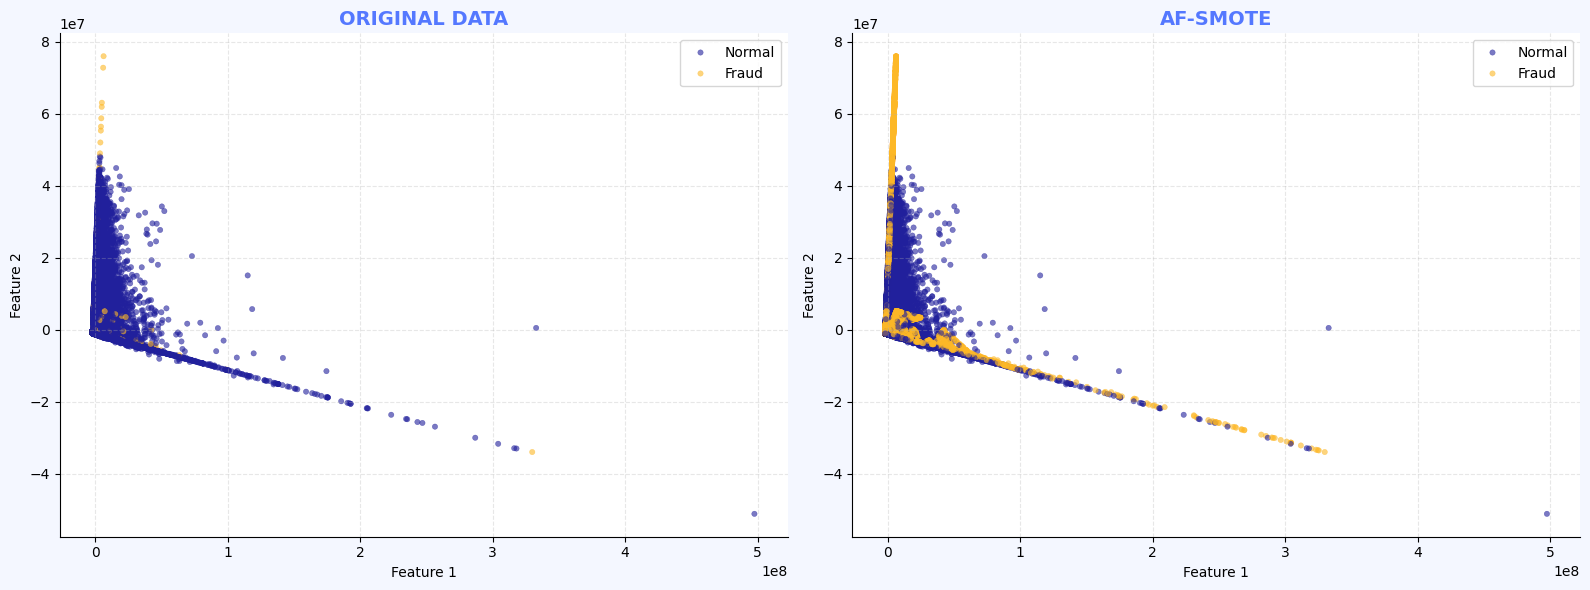

In [127]:
def visualize_resampling(X_before, y_before, X_after, y_after):
    # Fungsi internal untuk mengambil sampel visualisasi
    def sample_for_viz(X, y, max_normal=220976):
        # Konversi ke DataFrame sementara untuk mempermudah filter
        df_tmp = pd.DataFrame(X)
        df_tmp['target'] = np.array(y)
        
        # Pisahkan kelas
        df_fraud = df_tmp[df_tmp['target'] == 1]
        df_normal = df_tmp[df_tmp['target'] == 0]
        
        # Ambil sampel kelas normal jika terlalu banyak
        if len(df_normal) > max_normal:
            df_normal = df_normal.sample(n=max_normal, random_state=42)
            
        # Gabungkan kembali
        df_sampled = pd.concat([df_normal, df_fraud]).sample(frac=1, random_state=42)
        return df_sampled.drop(columns=['target']).values, df_sampled['target'].values

    # Ambil sampel dari data sebelum dan sesudah
    X_b_sample, y_b_sample = sample_for_viz(X_before, y_before)
    X_a_sample, y_a_sample = sample_for_viz(X_after, y_after)

    # PCA (Fit pada data asli, transform pada keduanya)
    pca = PCA(n_components=2, random_state=42)
    X_pca_before = pca.fit_transform(X_b_sample)
    X_pca_after = pca.transform(X_a_sample)

    # Visualisasi 
    COLOR_NORMAL = "#21209C"
    COLOR_FRAUD = "#FDB827"
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor("#F4F7FF")

    # Plot Sebelum
    sns.scatterplot(
        x=X_pca_before[:, 0], y=X_pca_before[:, 1], 
        hue=y_b_sample, palette={0: COLOR_NORMAL, 1: COLOR_FRAUD},
        alpha=0.6, s=15, ax=axes[0], edgecolor=None
    )
    axes[0].set_title('ORIGINAL DATA', fontsize=14, fontweight='bold', color="#5478FF")
    axes[0].set_xlabel('Feature 1')
    axes[0].set_ylabel('Feature 2')
    axes[0].grid(True, linestyle="--", alpha=0.3)

    # Plot Sesudah AF-SMOTE
    sns.scatterplot(
        x=X_pca_after[:, 0], y=X_pca_after[:, 1], 
        hue=y_a_sample, palette={0: COLOR_NORMAL, 1: COLOR_FRAUD},
        alpha=0.6, s=15, ax=axes[1], edgecolor=None
    )
    axes[1].set_title('AF-SMOTE', fontsize=14, fontweight='bold', color="#5478FF")
    axes[1].set_xlabel('Feature 1')
    axes[1].set_ylabel('Feature 2')
    axes[1].grid(True, linestyle="--", alpha=0.3)

    # legenda
    for ax in axes:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles, labels=['Normal', 'Fraud'], loc='upper right')
        # Hilangkan border atas dan kanan
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('visualisasi_afsmote.png', dpi=300, bbox_inches='tight')
    plt.show()

# visualisasi
visualize_resampling(X_train, y_train, X_train_balanced, y_train_balanced)

<div style="
    margin-top: 30px;
    padding: 16px 22px;
    border-left: 6px solid #5478FF;
    background: linear-gradient(135deg, #F8FBFF 0%, #EEF3FF 100%);
    border-radius: 8px;
">

<h2 style="
    margin: 0;
    color: #111FA2;
    font-size: 24px;
">
PEMODELAN MACHINE LEARNING
</h2>
</div>

## **Random Forest**

In [128]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_balanced, y_train_balanced)

y_pred_rf = rf_model.predict(X_test)

print("\n--- Hasil Evaluasi Random Forest ---")
print(classification_report(y_test, y_pred_rf))


--- Hasil Evaluasi Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



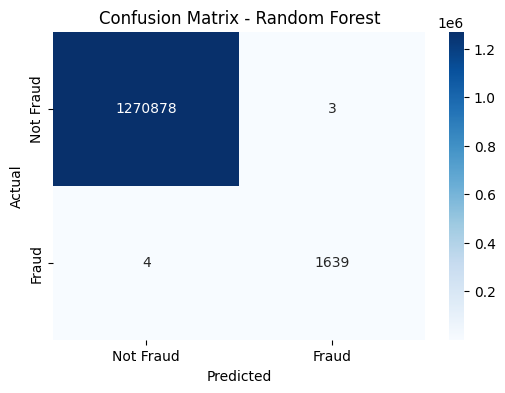

In [129]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Fraud', 'Fraud'], 
            yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()